In [1]:
import os
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
from torchsummary import summary

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
# Define paths
subset_df = pd.read_csv("subset_df.csv", index_col = 0)
subset_folder = "D:\\sem3\\Image-Data\\subset-photos\\"

# Define label categories
LABELS = ["food", "drink", "inside", "outside"]

#List available image files
image_files = set(os.listdir(subset_folder))

# Check how many images exist in the folder
print(f"Total images in folder: {len(image_files)}")
print(f"Total records in dataset: {len(subset_df)}")

# Check if all images in the dataset exist in the folder
missing_images = subset_df[subset_df['photo_id'].astype(str).isin(image_files)]
print(f"Missing images: {len(missing_images)}")

Total images in folder: 20000
Total records in dataset: 20000
Missing images: 0


In [4]:
# Randomly sample 5,000 records from the dataset
subset_df_sampled = subset_df.sample(n=5000, random_state=42).reset_index(drop=True)
subset_df_sampled.shape

(5000, 4)

In [5]:
import tensorflow as tf

subset_folder = os.path.abspath(subset_folder)  # Ensure absolute path
VALID_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp", ".gif"]

# Function to get a valid image path
def get_valid_image_path(image_path):
    image_path = image_path.numpy().decode("utf-8")  # Convert Tensor to string
    for ext in VALID_EXTENSIONS:
        full_path = os.path.join(subset_folder, image_path + ext)
        if os.path.exists(full_path):  # Check if file exists
            return full_path.encode("utf-8")  # Return byte string for TensorFlow compatibility
    return b""  # Return empty string if no valid file found

# Function to check if an image is valid
def is_valid_image(image_path):
    image_path = image_path.numpy().decode("utf-8")
    try:
        image = tf.io.read_file(image_path)
        image = tf.image.decode_jpeg(image, channels=3)  # Try decoding as JPEG
        return True
    except:
        return False

# Function to read and decode an image safely
def safe_decode_image(image_path):
    image = tf.io.read_file(image_path)  # Read file
    try:
        image = tf.image.decode_jpeg(image, channels=3)  # Try decoding
    except:
        return tf.zeros([64, 64, 3], dtype=tf.float32)  # Return a dummy black image

    image = tf.image.resize(image, [64, 64])  # Resize
    image = (image / 127.5) - 1  # Normalize to [-1, 1]
    return image

# Function to process each image
def load_image(image_path):
    valid_image_path = tf.py_function(get_valid_image_path, [image_path], tf.string)
    valid_image_path = tf.ensure_shape(valid_image_path, [])  # Ensure correct shape

    # Check if image is valid
    is_valid = tf.py_function(is_valid_image, [valid_image_path], tf.bool)

    # Decode only if valid
    image = tf.cond(is_valid, lambda: safe_decode_image(valid_image_path), lambda: tf.zeros([64, 64, 3], dtype=tf.float32))

    return image, is_valid  # Return image and validity flag

In [6]:
# Create TensorFlow dataset
image_paths = subset_df_sampled["photo_id"].astype(str).tolist()
dataset = tf.data.Dataset.from_tensor_slices(image_paths)

# Load images and check validity
dataset = dataset.map(lambda x: load_image(x), num_parallel_calls=tf.data.AUTOTUNE)

# Filter out invalid (corrupt) images
dataset = dataset.filter(lambda image, is_valid: is_valid)

# Remove validity flag, keep only images
dataset = dataset.map(lambda image, _: image, num_parallel_calls=tf.data.AUTOTUNE)

dataset = dataset.batch(64).prefetch(tf.data.AUTOTUNE)

In [7]:
def tf_to_torch(batch):
    batch_numpy = batch.numpy()  # Convert to NumPy
    return torch.tensor(batch_numpy, dtype=torch.float32).permute(0, 3, 1, 2)  # Convert [B, H, W, C] → [B, C, H, W]

for tf_batch in dataset:
    torch_batch = tf_to_torch(tf_batch)  # Convert TensorFlow batch to PyTorch tensor
    torch_batch = torch_batch.to(device)  # Move to GPU
    pass  # Process batch as needed

In [8]:
import torch.nn as nn

class DiffusionModel(nn.Module):
    def __init__(self, timesteps=1000, beta_start=0.0001, beta_end=0.02):
        super(DiffusionModel, self).__init__()
        self.timesteps = timesteps
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Define noise schedule
        self.beta = torch.linspace(beta_start, beta_end, timesteps, device=self.device)  
        self.alpha = 1.0 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)  # Cumulative product

    def forward_diffusion(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)  # Standard Gaussian noise

        # Ensure `t` is tensor-based for indexing
        t = t.to(self.device)
        sqrt_alpha_bar = self.alpha_bar[t].sqrt().view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_bar = (1 - self.alpha_bar[t]).sqrt().view(-1, 1, 1, 1)
        
        return sqrt_alpha_bar * x0 + sqrt_one_minus_alpha_bar * noise, noise

# Initialize diffusion model
diffusion = DiffusionModel().to(device)

In [9]:
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        
        # Encoding layers
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        # Decoding layers
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(128 + 128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.dec3 = nn.Conv2d(64 + 64, 3, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        # Encoding path
        x1 = self.enc1(x)  # (B, 64, 64, 64)
        x2 = self.enc2(x1)  # (B, 128, 32, 32)
        x3 = self.enc3(x2)  # (B, 256, 16, 16)

        # Decoding path
        x = self.dec1(x3)  # (B, 128, 32, 32)
        x = torch.cat([x, x2], dim=1)  # Skip connection

        x = self.dec2(x)  # (B, 64, 64, 64)
        x = torch.cat([x, x1], dim=1)  # Skip connection

        x = self.dec3(x)  # Final output (B, 3, 64, 64)

        return torch.tanh(x)  # Normalize output to [-1, 1]

# Initialize model
unet = UNet().to(device)

In [10]:
import torch.optim as optim
from tqdm import tqdm
import time

# Hyperparameters
epochs = 500
lr = 1e-4

# Optimizer for U-Net model
optimizer = optim.Adam(unet.parameters(), lr=lr)

# Training loop
for epoch in range(epochs):
    unet.train()
    running_loss = 0.0

    # Set up progress bar with description
    epoch_start_time = time.time()
    progress_bar = tqdm(dataset, desc=f"Epoch {epoch+1}/{epochs}", leave=False, ncols=100)

    for i, tf_batch in enumerate(progress_bar):
        # Convert TensorFlow tensor to NumPy, then to PyTorch tensor
        images = torch.tensor(tf_batch.numpy()).permute(0, 3, 1, 2)  # (B, C, H, W)
        images = images.to(device)  # Move images to GPU or CPU

        # Sample random timesteps for each image in the batch
        t = torch.randint(0, diffusion.timesteps, (images.size(0),), device=device)

        # Apply forward diffusion process
        noisy_images, noise = diffusion.forward_diffusion(images, t)

        # Predict the noise (denoising)
        optimizer.zero_grad()
        predicted_noise = unet(noisy_images)

        # Compute loss (L2 loss between predicted noise and actual noise)
        loss = F.mse_loss(predicted_noise, noise)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Update progress bar with current loss and elapsed time
        elapsed_time = time.time() - epoch_start_time
        progress_bar.set_postfix(loss=running_loss / (i + 1), elapsed_time=f"{elapsed_time:.2f}s")

    # Print average loss for the epoch
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss / (subset_df_sampled.shape[0] // 64):.4f}")

Epoch [1/500], Loss: 0.5812


Epoch [2/500], Loss: 0.3166


Epoch [3/500], Loss: 0.2768


Epoch [4/500], Loss: 0.2653


Epoch [5/500], Loss: 0.2535


...

Epoch [496/500], Loss: 0.1950


Epoch [497/500], Loss: 0.1927


Epoch [498/500], Loss: 0.1963


Epoch [499/500], Loss: 0.1946


Epoch [500/500], Loss: 0.1977


In [11]:
summary(unet, input_size=(3, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 64, 64]           1,792
       BatchNorm2d-2           [-1, 64, 64, 64]             128
              ReLU-3           [-1, 64, 64, 64]               0
            Conv2d-4          [-1, 128, 32, 32]          73,856
       BatchNorm2d-5          [-1, 128, 32, 32]             256
              ReLU-6          [-1, 128, 32, 32]               0
            Conv2d-7          [-1, 256, 16, 16]         295,168
       BatchNorm2d-8          [-1, 256, 16, 16]             512
              ReLU-9          [-1, 256, 16, 16]               0
  ConvTranspose2d-10          [-1, 128, 32, 32]         295,040
      BatchNorm2d-11          [-1, 128, 32, 32]             256
             ReLU-12          [-1, 128, 32, 32]               0
  ConvTranspose2d-13           [-1, 64, 64, 64]         147,520
      BatchNorm2d-14           [-1, 64,

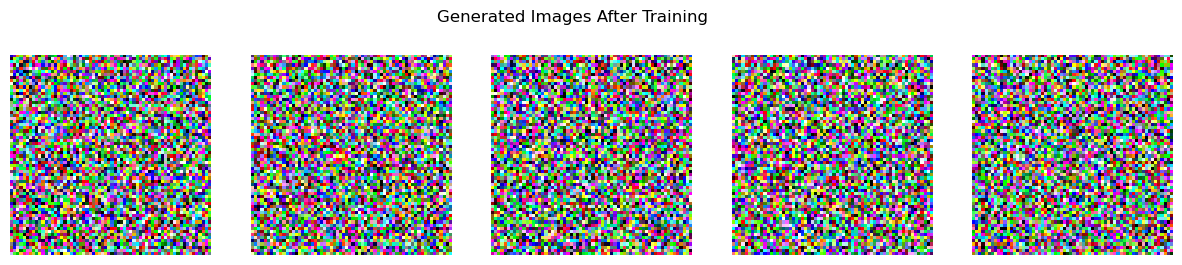

In [12]:
import matplotlib.pyplot as plt

# Function to plot generated images
def show_generated_images(images):
    images = images.cpu().detach().numpy()  # Move images to CPU and convert to NumPy
    images = (images * 0.5) + 0.5  # Rescale the images if they were normalized
    
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))  # Display 5 images
    for i, ax in enumerate(axes):
        ax.imshow(images[i].transpose(1, 2, 0))  # Convert from (C, H, W) to (H, W, C)
        ax.axis('off')
    plt.suptitle("Generated Images After Training")
    plt.show()

# After completing the training loop:
unet.eval()  # Set model to evaluation mode
with torch.no_grad():  # No gradients required for inference
    # Generate a batch of images (for example, using a sample noisy image batch)
    sample_images = torch.randn(5, 3, 64, 64).to(device)  # Example random images as input
    generated_images = unet(sample_images)  # Generate images from U-Net

    # Display the generated images
    show_generated_images(generated_images)

In [ ]:
from torchvision import models

# Load the pretrained Inception v3 model
inception_model = models.inception_v3(pretrained=True, transform_input=False).eval().to(device)

# Calculate the Inception Score of generated images.
def calculate_inception_score(images, batch_size=32, splits=10):
    def get_predicted_class_probabilities(images):
        with torch.no_grad():
            # Resize images to 299x299 (required for Inception v3)
            images_resized = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
            # Forward pass through Inception v3
            logits = inception_model(images_resized)
            probabilities = F.softmax(logits, dim=1)
        return probabilities

    split_scores = []
    num_images = images.shape[0]
    split_size = num_images // splits  # Ensuring each split has equal samples

    for i in range(splits):
        start_idx = i * split_size
        end_idx = start_idx + split_size if i < splits - 1 else num_images
        batch_images = images[start_idx:end_idx].to(device)

        prob = get_predicted_class_probabilities(batch_images)
        kl_divergence = prob * (prob.log() - prob.mean(dim=0, keepdim=True).log())
        kl_divergence = kl_divergence.sum(dim=1).mean()

        split_scores.append(np.exp(kl_divergence.item()))

    return np.mean(split_scores), np.std(split_scores)

# Example usage on generated images
generated_images = ...  # Generated image tensor from DDPM
inception_score_mean, inception_score_std = calculate_inception_score(generated_images)
print(f"Inception Score: {inception_score_mean} ± {inception_score_std}")

In [ ]:
from scipy.linalg import sqrtm

# Load pretrained Inception v3 model
inception_model = models.inception_v3(pretrained=True, transform_input=False).eval().to(device)

def get_features(images):
    # Resize images and extract feature vectors from Inception v3
    with torch.no_grad():
        images_resized = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
        features = inception_model(images_resized)
    return features.view(features.size(0), -1)  

def calculate_fid(real_images, generated_images):
    # Get features for real and generated images
    real_features = get_features(real_images)
    gen_features = get_features(generated_images)

    # Compute mean and covariance of features
    mu_real, sigma_real = torch.mean(real_features, dim=0), torch.cov(real_features.T)
    mu_gen, sigma_gen = torch.mean(gen_features, dim=0), torch.cov(gen_features.T)

    # Compute sqrt of product of covariance matrices
    diff = mu_real - mu_gen
    cov_mean = sqrtm((sigma_real @ sigma_gen).cpu().numpy())  

    # Handle numerical issues
    if np.iscomplexobj(cov_mean):
        cov_mean = cov_mean.real

    fid_score = (diff @ diff + torch.trace(sigma_real + sigma_gen - 2 * torch.tensor(cov_mean, device=device))).item()
    return fid_score

# Extract real images from TensorFlow dataset and convert to PyTorch tensors
real_images = []
for i, tf_batch in enumerate(dataset):
    torch_batch = tf_to_torch(tf_batch).to(device)  
    real_images.append(torch_batch)
    if i >= 10:  # Use limited real images for FID calculation
        break

real_images = torch.cat(real_images, dim=0)

# Ensure generated images are also on the correct device
generated_images = generated_images.to(device)

# Compute FID
fid_score = calculate_fid(real_images, generated_images)
print(f"FID Score: {fid_score}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example IS and FID values (these should come from your evaluation step)
inception_scores = [inception_score_mean]  # Add scores for multiple evaluations if needed
fid_scores = [fid_score]  # Add FID scores for multiple evaluations

# Create the figure for IS and FID
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Inception Score
axes[0].bar([1], inception_scores, color='royalblue')
axes[0].set_title('Inception Score')
axes[0].set_ylabel('Score')
axes[0].set_xticks([1])
axes[0].set_xticklabels(['Generated Images'])
axes[0].set_ylim([0, max(inception_scores) + 1])

# Plot FID Score
axes[1].bar([1], fid_scores, color='darkorange')
axes[1].set_title('Frechet Inception Distance')
axes[1].set_ylabel('Score')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Generated vs Real Images'])
axes[1].set_ylim([0, max(fid_scores) + 10])

# Show the plots
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def plot_feature_distribution(real_features, gen_features):
    """Plot the feature distribution of real vs generated images"""
    real_features = real_features.cpu().numpy()
    gen_features = gen_features.cpu().numpy()

    # Create the figure for the distributions
    plt.figure(figsize=(10, 6))

    # Plot the histograms of real vs generated features
    sns.kdeplot(real_features.flatten(), color='blue', label='Real Images', fill=True)
    sns.kdeplot(gen_features.flatten(), color='red', label='Generated Images', fill=True)

    plt.title('Real vs Generated Feature Distributions')
    plt.xlabel('Feature Value')
    plt.ylabel('Density')
    plt.legend()

    plt.show()

# Example: Assuming real_features and gen_features are the output of the feature extraction
real_features = get_features(real_images)
gen_features = get_features(generated_images)

plot_feature_distribution(real_features, gen_features)

In [ ]:
import matplotlib.pyplot as plt

# Save and display 5 generated images
def save_generated_images(images, path="generated_images.png"):
    fig, axes = plt.subplots(1, 5, figsize=(15, 5))
    for i, img in enumerate(images[:5]):
        axes[i].imshow(img.permute(1, 2, 0).cpu().numpy())
        axes[i].axis('off')
    plt.savefig(path)
    plt.show()

# Save and display 5 generated images
save_generated_images(generated_images)